In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE


In [ ]:
df = pd.read_excel("PCOS_data_without_infertility.xlsx", sheet_name="Full_new")

print("Shape:", df.shape)
df.head()


Shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
df.drop(columns=["Sl. No", "Patient File No.", "Unnamed: 44"], inplace=True, errors="ignore")

# Check missing values
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Marraige Status (Yrs)     1
Pregnant(Y/N)             0
No. of aborptions         0
  I   beta-HCG(mIU/mL)    0
II    beta-HCG(mIU/mL)    0
FSH(mIU/mL)               0
LH(mIU/mL)                0
FSH/LH                    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
AMH(ng/mL)                0
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)           1
Reg.Exercise(Y/N)   

In [ ]:
X = df.drop(columns=["PCOS (Y/N)"])
y = df["PCOS (Y/N)"]

# Convert Yes/No columns to binary (0/1)
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].map({'Y': 1, 'N': 0})

# Fill numeric NaN with median
num_cols = X.select_dtypes(include=["float64", "int64"]).columns
X[num_cols] = X[num_cols].apply(lambda col: col.fillna(col.median()))

# Fill categorical/binary NaN with mode
cat_cols = X.select_dtypes(exclude=["float64", "int64"]).columns
X[cat_cols] = X[cat_cols].apply(lambda col: col.fillna(col.mode()[0]))

# Double-check: replace any leftover NaN with 0
X = X.fillna(0)

print("Remaining missing values:", X.isnull().sum().sum())


Remaining missing values: 0


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Drop zero-variance columns
selector = VarianceThreshold(threshold=0.0)
X_reduced = selector.fit_transform(X)

# Keep feature names
selected_features = X.columns[selector.get_support()]
X = pd.DataFrame(X_reduced, columns=selected_features)

print("Final features after dropping constants:", X.shape[1])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale only non-constant numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Final features after dropping constants: 39
Train size: (378, 39) Test size: (163, 39)


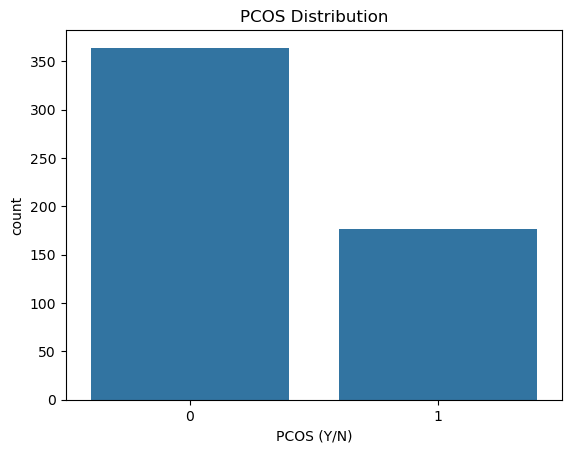

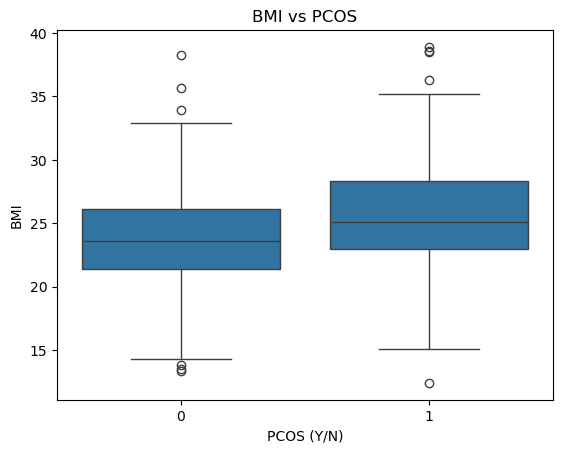

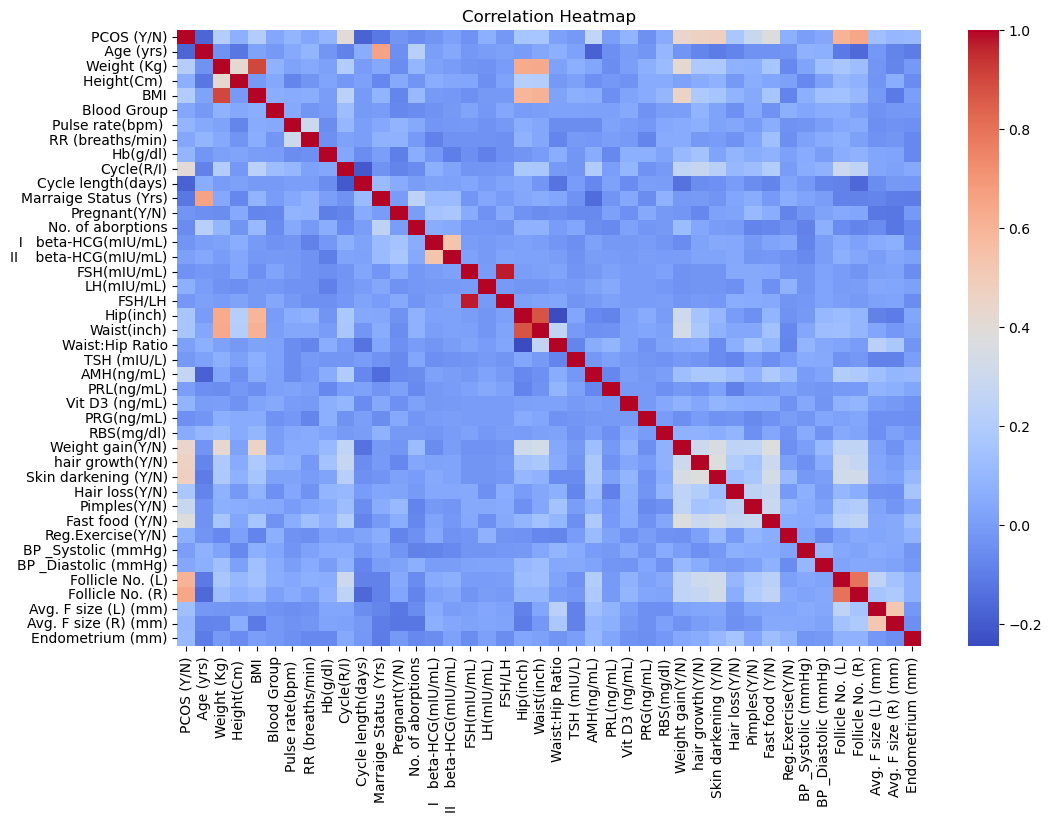

In [ ]:
df_numeric = df.apply(pd.to_numeric, errors="coerce")

# Fill NaN created during conversion
df_numeric = df_numeric.fillna(0)

# --- PCOS distribution
sns.countplot(x=y)
plt.title("PCOS Distribution")
plt.show()

# --- BMI distribution by PCOS
sns.boxplot(x=y, y=X["BMI"])
plt.title("BMI vs PCOS")
plt.show()

# --- Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       110
           1       0.77      0.75      0.76        53

    accuracy                           0.85       163
   macro avg       0.83      0.82      0.82       163
weighted avg       0.85      0.85      0.85       163



In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_rf_pred))

# XGBoost
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train)
y_xgb_pred = xgb.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test, y_xgb_pred))



Random Forest Results:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       110
           1       0.89      0.77      0.83        53

    accuracy                           0.90       163
   macro avg       0.89      0.86      0.88       163
weighted avg       0.90      0.90      0.89       163

XGBoost Results:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       110
           1       0.85      0.77      0.81        53

    accuracy                           0.88       163
   macro avg       0.87      0.85      0.86       163
weighted avg       0.88      0.88      0.88       163



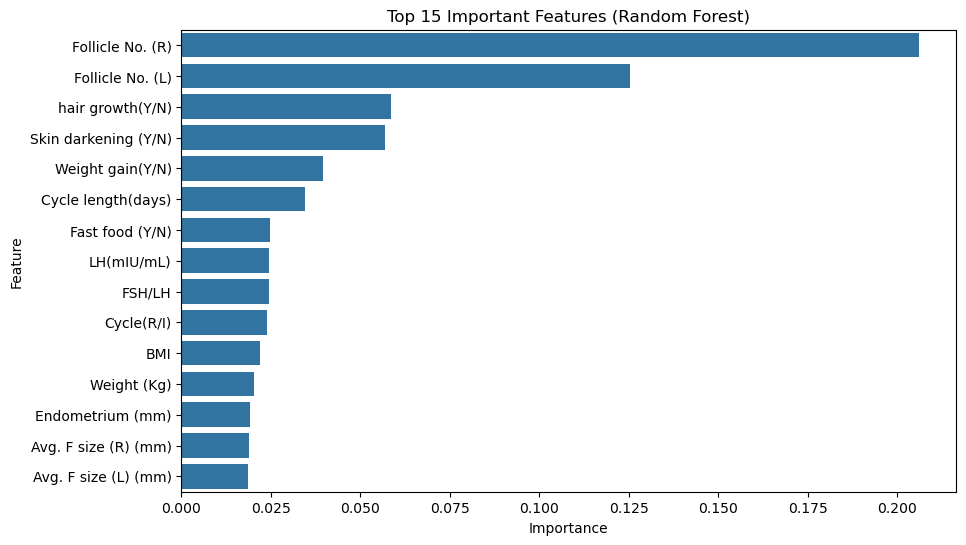

In [ ]:

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({"Feature": features, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Important Features (Random Forest)")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.846626   0.769231  0.754717  0.761905  0.822813
1        Random Forest  0.895706   0.891304  0.773585  0.828283  0.864065
2              XGBoost  0.883436   0.854167  0.773585  0.811881  0.854974


<Figure size 800x600 with 0 Axes>

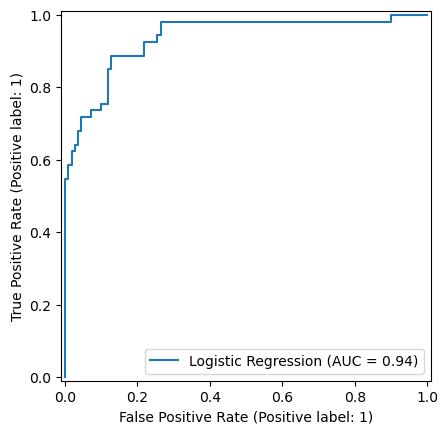

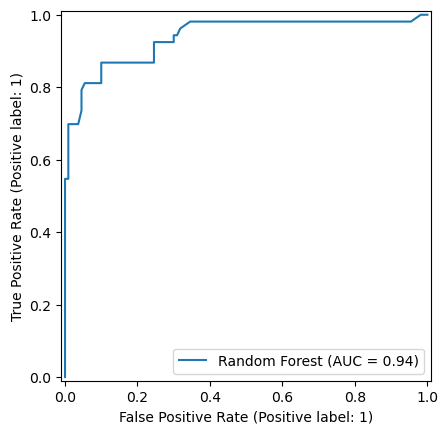

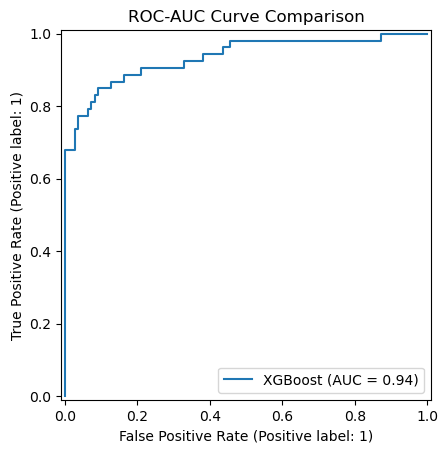

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(log_model, X_test_scaled, y_test, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
RocCurveDisplay.from_estimator(xgb, X_test, y_test, name="XGBoost")

plt.title("ROC-AUC Curve Comparison")
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts())
print("After SMOTE:", y_res.value_counts())


Before SMOTE: PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64
After SMOTE: PCOS (Y/N)
0    364
1    364
Name: count, dtype: int64


In [ ]:
import joblib

joblib.dump(rf, "pcos_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']